In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [2]:
df_india = pd.read_csv('/content/Unemployment in India.csv')
df_rate = pd.read_csv('/content/Unemployment_Rate_upto_11_2020.csv')

In [3]:
print("Unemployment in India (df_india) - Head:")
display(df_india.head())
print("\nUnemployment in India (df_india) - Info:")
df_india.info()

Unemployment in India (df_india) - Head:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



Unemployment in India (df_india) - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [4]:
print("\nUnemployment Rate upto 11-2020 (df_rate) - Head:")
display(df_rate.head())
print("\nUnemployment Rate upto 11-2020 (df_rate) - Info:")
df_rate.info()


Unemployment Rate upto 11-2020 (df_rate) - Head:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



Unemployment Rate upto 11-2020 (df_rate) - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [5]:
df_india.columns = df_india.columns.str.strip()
df_rate.columns = df_rate.columns.str.strip()

print("Columns of df_india after stripping whitespace:", df_india.columns.tolist())
print("Columns of df_rate after stripping whitespace:", df_rate.columns.tolist())

Columns of df_india after stripping whitespace: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Columns of df_rate after stripping whitespace: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [6]:
df_india['Date'] = pd.to_datetime(df_india['Date'], dayfirst=True)
df_rate['Date'] = pd.to_datetime(df_rate['Date'], dayfirst=True)

print("Data type of 'Date' column in df_india:", df_india['Date'].dtype)
print("Data type of 'Date' column in df_rate:", df_rate['Date'].dtype)

Data type of 'Date' column in df_india: datetime64[ns]
Data type of 'Date' column in df_rate: datetime64[ns]


In [7]:
df_india = df_india.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment Rate',
                                    'Estimated Employed': 'Employed',
                                    'Estimated Labour Participation Rate (%)': 'Labour Participation Rate'})
display(df_india.head())

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
df_rate = df_rate.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment Rate',
                                  'Estimated Employed': 'Employed',
                                  'Estimated Labour Participation Rate (%)': 'Labour Participation Rate',
                                  'Region.1': 'Region'})
display(df_rate.head())

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [9]:
print("Missing values in df_india:")
display(df_india.isnull().sum())

print("\nMissing values in df_rate:")
display(df_rate.isnull().sum())

Missing values in df_india:


,0
Region,28
Date,28
Frequency,28
Unemployment Rate,28
Employed,28
Labour Participation Rate,28
Area,28



Missing values in df_rate:


,0
Region,0
Date,0
Frequency,0
Unemployment Rate,0
Employed,0
Labour Participation Rate,0
Region,0
longitude,0
latitude,0


In [10]:
print("Duplicate rows in df_india:", df_india.duplicated().sum())
print("Duplicate rows in df_rate:", df_rate.duplicated().sum())

Duplicate rows in df_india: 27
Duplicate rows in df_rate: 0


In [11]:
df_india['Month'] = df_india['Date'].dt.month
df_india['Month_int'] = df_india['Month'].apply(lambda x: int(x))
df_india['Month_name'] = df_india['Month_int'].apply(lambda x: calendar.month_abbr[x])
df_india['Year'] = df_india['Date'].dt.year

df_rate['Month'] = df_rate['Date'].dt.month
df_rate['Month_int'] = df_rate['Month'].apply(lambda x: int(x))
df_rate['Month_name'] = df_rate['Month_int'].apply(lambda x: calendar.month_abbr[x])
df_rate['Year'] = df_rate['Date'].dt.year

display(df_india.head())
display(df_rate.head())

ValueError: cannot convert float NaN to integer

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_india, x='Month_name', y='Unemployment Rate', hue='Year')
plt.title('Unemployment Rate in India Over Months by Year')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

ValueError: Could not interpret value `Month_name` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

/tmp/ipykernel_4887/4149372850.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_india, x='Region', y='Unemployment Rate', ci=None)


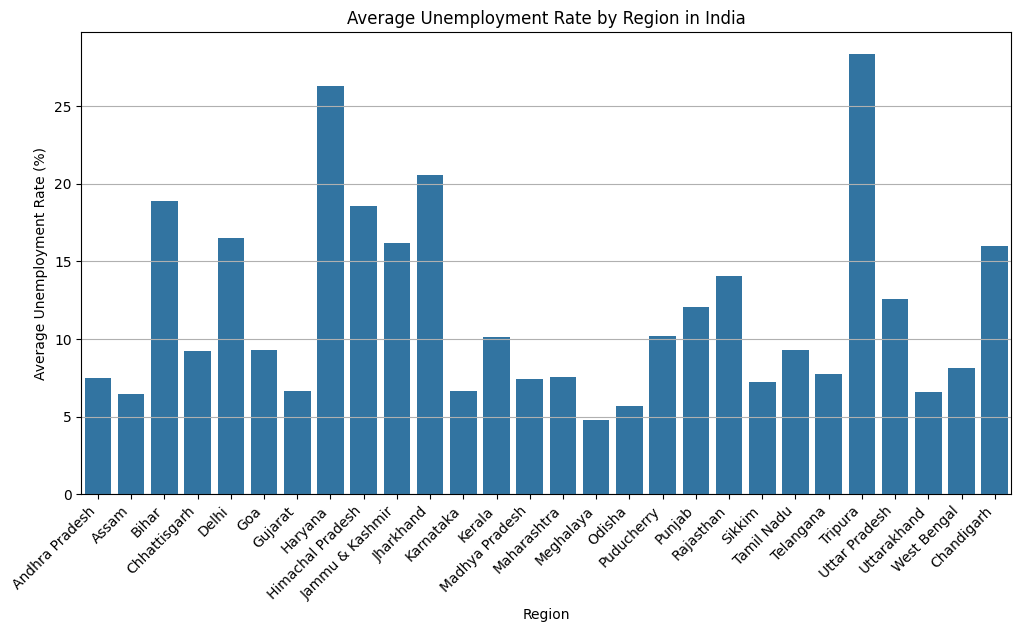

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_india, x='Region', y='Unemployment Rate', ci=None)
plt.title('Average Unemployment Rate by Region in India')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_rate, x='Month_name', y='Unemployment Rate', hue='Region')
plt.title('Unemployment Rate by Region Over Months (upto 11-2020)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Month_name` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [15]:
region_unemployment = df_india.groupby(['Region', 'Month_name'])['Unemployment Rate'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.heatmap(pd.pivot_table(region_unemployment, values='Unemployment Rate', index='Region', columns='Month_name'), annot=True, cmap='viridis', fmt=".2f")
plt.title('Average Unemployment Rate by Region and Month')
plt.xlabel('Month')
plt.ylabel('Region')
plt.show()

KeyError: 'Month_name'

/tmp/ipykernel_4887/4157839784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_unemployment_overall, x='Region', y='Unemployment Rate', palette='coolwarm')


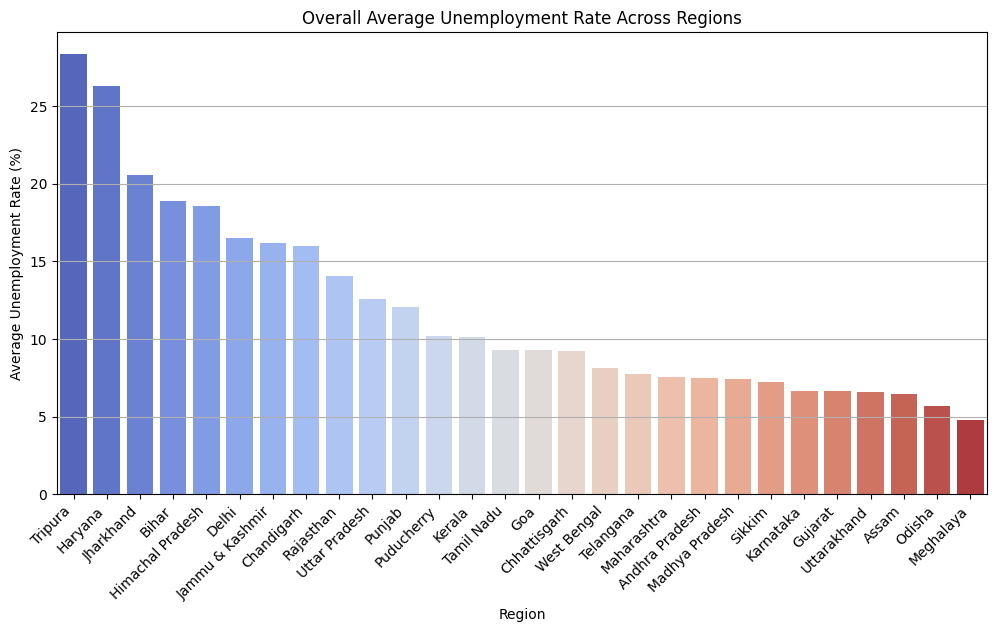

In [16]:
avg_unemployment_overall = df_india.groupby('Region')['Unemployment Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_unemployment_overall, x='Region', y='Unemployment Rate', palette='coolwarm')
plt.title('Overall Average Unemployment Rate Across Regions')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()